# 5. Populations, regions and morphometrics

Comparing groups of cells.

There is no `Trees` class in pytrees: a population is a plain `list[Tree]`, and
`stats_tree` returns tidy **pandas DataFrames**, so the usual
grouping/filtering/plotting all works directly.

This notebook builds its own synthetic population so it runs anywhere with no
external data files. Everything shown applies unchanged to real
reconstructions loaded with `load_swc`, `load_mtr` or `load_neurolucida`.

In [1]:
import numpy as np
import pandas as pd
import pytrees as pt

## Building a population with regions

We grow cells with `MST_tree` over point clouds, then tag nodes into
anatomical-style layers by their distance from the soma — giving us the
`rnames`/`R` structure that real reconstructions carry.

In [2]:
def make_cell(seed, n_points=220, spread=90.0, bf=0.4):
    """A synthetic neuron with a soma and three concentric dendritic layers."""
    rng = np.random.default_rng(seed)
    pts = rng.normal(0.0, spread, size=(n_points, 3))
    pts[:, 2] *= 0.2                      # flattish arbor
    pts[0] = 0.0                          # start at the origin
    tree, _connected = pt.MST_tree(pts[:, 0], pts[:, 1], pts[:, 2], bf=bf, thr=70.0, full_output=True)[:2]
    tree = pt.quaddiameter_tree(pt.repair_tree(tree))

    # tag regions by radial distance -- stand-ins for real anatomical layers
    eucl = pt.eucl_tree(tree)
    R = np.digitize(eucl, [20.0, 60.0, 110.0])
    tree.R = R.astype(int)
    tree.rnames = ["soma", "proximal", "medial", "distal"]
    tree.name = f"cell{seed:02d}"
    return tree


population = [make_cell(seed) for seed in range(8)]
for c in population[:3]:
    print(c)

Tree(name='cell00', n_nodes=244, regions=[soma, proximal, medial, distal])
Tree(name='cell01', n_nodes=246, regions=[soma, proximal, medial, distal])
Tree(name='cell02', n_nodes=237, regions=[soma, proximal, medial, distal])


## Regions

`region_nodes` replaces the MATLAB idiom
`find(tree.R == find(strcmp(tree.rnames,'soma')))`.

In [3]:
cell0 = population[0]
length = pt.len_tree(cell0)

for name in cell0.rnames:
    nodes = cell0.region_nodes(name)
    if len(nodes):
        print(f"  {name:10s} {len(nodes):4d} nodes  {length[nodes].sum():8.1f} um")

# combine regions in one call
dendritic = cell0.region_nodes("proximal", "medial", "distal")
print(f"\nall dendritic layers: {len(dendritic)} nodes")

  soma          7 nodes      31.7 um
  proximal     49 nodes     750.0 um
  medial       78 nodes    1563.1 um
  distal      110 nodes    3336.8 um

all dendritic layers: 237 nodes


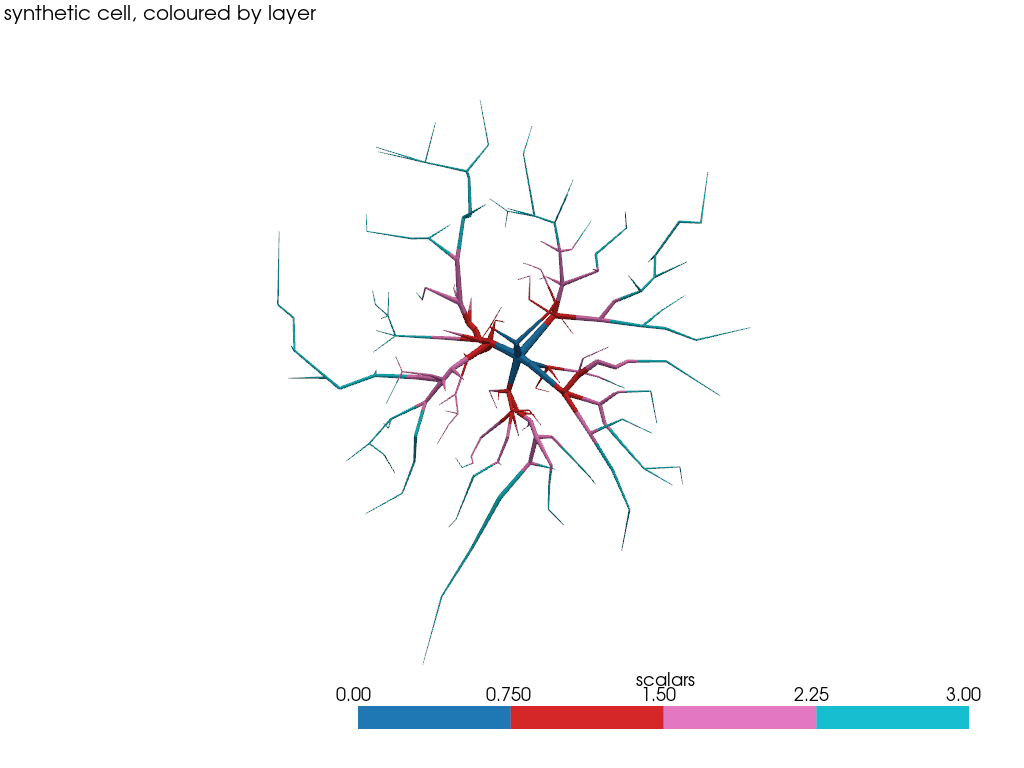

In [4]:
pl = pt.plot_tree(cell0, scalars=cell0.R.astype(float), cmap="tab10",
                  mode="tube", res=8, categories=True)
pl.add_text("synthetic cell, coloured by layer", font_size=10)
pl.camera_position = "xy"
pl.screenshot("tut05_regions.png")
pl.close()

from IPython.display import Image
Image("tut05_regions.png")

> Note `scalars` is the **full-tree** array, even if you pass `nodes=` to draw
> only part of the cell. `nodes=` controls what gets *drawn*; the underlying
> mesh still carries every node's coordinates. A sliced array raises a clear
> `ValueError`.

## Population statistics

`stats_tree` accepts one tree, a flat list (one group), or a list of lists
(several named groups).

In [5]:
# two groups differing in how tightly they branch
group_a = [make_cell(s, bf=0.2) for s in range(10, 14)]
group_b = [make_cell(s, bf=0.8) for s in range(20, 24)]

res = pt.stats_tree([group_a, group_b], group_names=["bf=0.2", "bf=0.8"])
print("returned frames:", list(res))
res["summary"][["group", "tree", "len", "bpoints", "maxbo", "mblen", "mpeucl"]]

returned frames: ['summary', 'points', 'branches']


,group,tree,len,bpoints,maxbo,mblen,mpeucl
0,bf=0.2,0,5349.117963,72,13.0,37.669831,0.724810
1,bf=0.2,1,5229.675790,76,14.0,34.405754,0.717284
2,bf=0.2,2,5329.150936,76,13.0,34.381609,0.727710
3,bf=0.2,3,5281.335263,73,12.0,35.684688,0.733213
4,bf=0.8,0,7699.688558,100,25.0,45.831451,0.959018
5,bf=0.8,1,7469.761973,99,23.0,43.428823,0.956138
6,bf=0.8,2,7853.730672,102,25.0,44.371331,0.960297
7,bf=0.8,3,7701.914576,111,24.0,44.778537,0.960962


Three frames, each at a different granularity:

- **`summary`** — one row per tree (total length, branch-point count, ...)
- **`points`** — one row per branch/termination point (branch order, path
  length, tortuosity, branching angle)
- **`branches`** — one row per dissected branch (its length)

They're separate frames rather than one wide table because they're genuinely
different lengths: one entry per *tree* vs per *point* vs per *branch*.

In [6]:
print("summary :", res["summary"].shape)
print("points  :", res["points"].shape)
print("branches:", res["branches"].shape)

res["summary"].groupby("group")[["len", "bpoints", "maxbo"]].agg(["mean", "std"])

summary : (8, 16)
points  : (1426, 6)
branches: (1286, 3)


len             bpoints            maxbo          
               mean         std    mean       std   mean       std
group                                                             
bf=0.2  5297.319988   53.315065   74.25  2.061553  13.00  0.816497
bf=0.8  7681.273945  158.370631  103.00  5.477226  24.25  0.957427

Because these are ordinary DataFrames, comparison plots are one-liners.

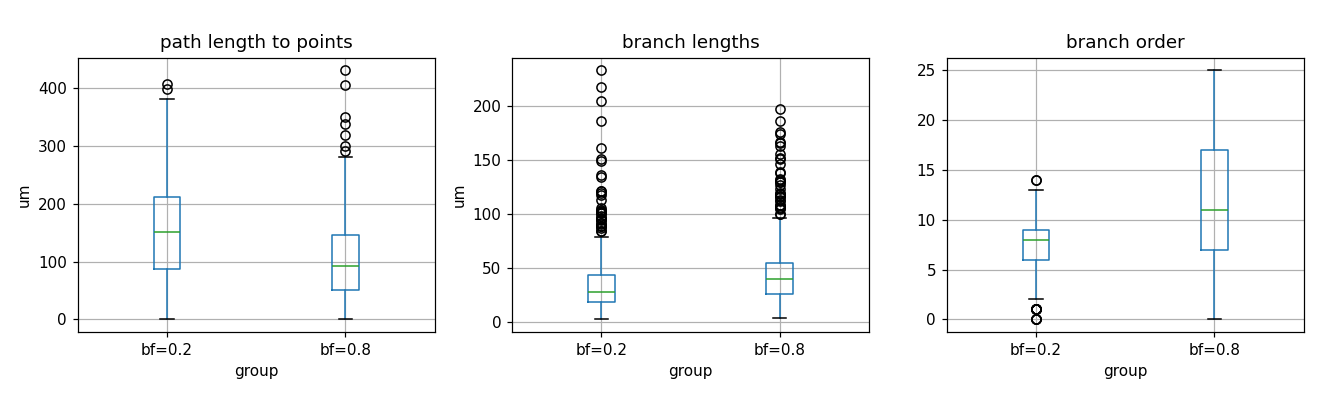

In [7]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
res["points"].boxplot(column="Plen", by="group", ax=axes[0])
axes[0].set_title("path length to points"); axes[0].set_ylabel("um")
res["branches"].boxplot(column="blen", by="group", ax=axes[1])
axes[1].set_title("branch lengths"); axes[1].set_ylabel("um")
res["points"].boxplot(column="BO", by="group", ax=axes[2])
axes[2].set_title("branch order")
fig.suptitle("")
fig.tight_layout(); fig.savefig("tut05_group_stats.png", dpi=110); plt.close(fig)

from IPython.display import Image
Image("tut05_group_stats.png")

The higher balancing factor produces shorter paths to the soma — the expected
consequence of `bf` trading wiring length against path length (notebook 2).

## Sholl analysis

Intersections of the arbor with concentric spheres around the soma — the
classic measure of how branching density varies with distance.

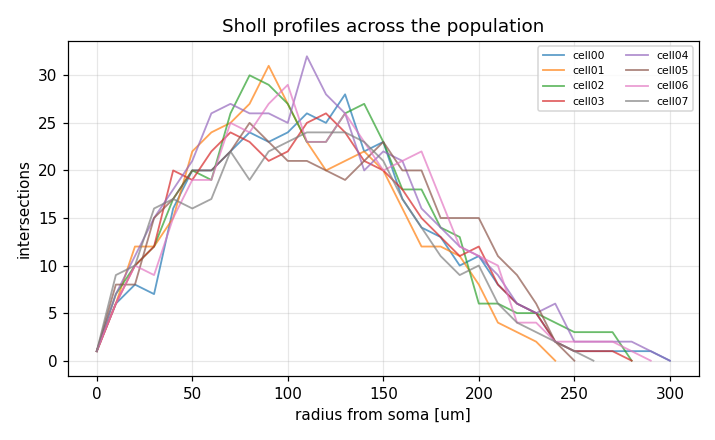

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 4))
for c in population:
    sh = pt.sholl_tree(c, 20.0, warn_double=False)
    ax.plot(sh.dd / 2, sh.s, alpha=0.7, lw=1.2, label=c.name)
ax.set_xlabel("radius from soma [um]"); ax.set_ylabel("intersections")
ax.set_title("Sholl profiles across the population")
ax.grid(alpha=0.3); ax.legend(fontsize=7, ncol=2)
fig.tight_layout(); fig.savefig("tut05_sholl.png", dpi=110); plt.close(fig)

from IPython.display import Image
Image("tut05_sholl.png")

`extras=True` computes each cell's Sholl profile on a **common radius grid**,
which is what you need to average across a population — plus convex-hull
volume and mean branch-point asymmetry.

In [9]:
res_x = pt.stats_tree(population, extras=True)
sholl = res_x["sholl"]
mean_profile = sholl.groupby("radius")["count"].mean()
print(f"sholl frame {sholl.shape}, common grid of {sholl['radius'].nunique()} radii")
print(f"population-mean profile peaks at radius {mean_profile.idxmax()/2:.0f} um")

res_x["summary"][["tree", "len", "bpoints", "hull_volume", "masym"]]

sholl frame (5200, 4), common grid of 650 radii
population-mean profile peaks at radius 78 um


,tree,len,bpoints,hull_volume,masym
0,0,5681.621654,82,7.750296e+06,0.319072
1,1,5163.948005,87,6.864151e+06,0.307530
2,2,5814.763463,79,7.504905e+06,0.325173
3,3,5557.845245,80,8.320284e+06,0.325229
4,4,6018.823658,81,9.298529e+06,0.342198
5,5,5661.525734,78,8.010645e+06,0.333341
6,6,5628.792843,77,9.169492e+06,0.348389
7,7,5068.307503,81,6.476391e+06,0.319498


## Overview of the whole population

`spread_trees` lays cells out on a non-overlapping grid.

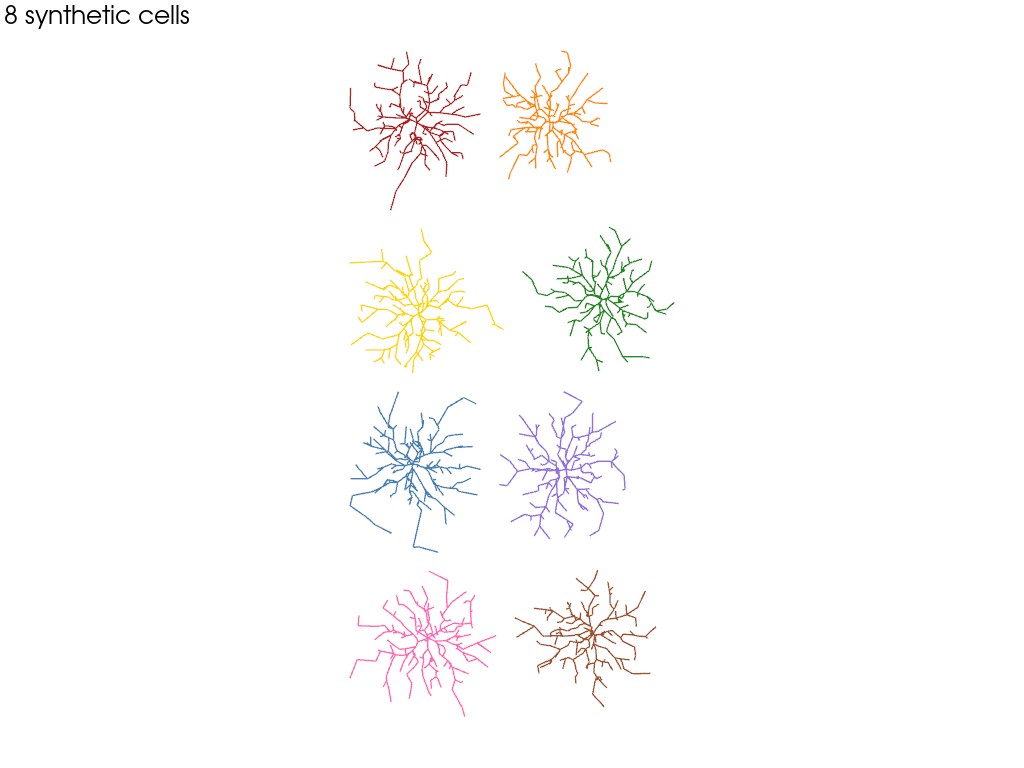

In [10]:
colors = ["firebrick", "darkorange", "gold", "forestgreen",
          "steelblue", "mediumpurple", "hotpink", "sienna"]

pl = None
for c, color in zip(pt.spread_trees(population, dx=60.0, dy=60.0), colors):
    pl = pt.plot_tree(c, color=color, mode="line", plotter=pl)
pl.camera_position = "xy"
pl.add_text(f"{len(population)} synthetic cells", font_size=10)
pl.screenshot("tut05_population.png")
pl.close()

from IPython.display import Image
Image("tut05_population.png")

## Working with real data

Everything above applies unchanged to real reconstructions:

```python
cells = pt.load_mtr("population.mtr")        # MATLAB archive, often many cells
cells = pt.load_neurolucida("cell.ASC")      # NeuroLucida
cells = [pt.load_swc(p) for p in Path("swc").glob("*.swc")]

cells = [pt.repair_tree(c) for c in cells]   # always worth doing after loading
res = pt.stats_tree(cells)
```

## Where next

- [`docs/guide.md`](../docs/guide.md) — the full task-oriented guide
- [`docs/matlab-migration.md`](../docs/matlab-migration.md) — porting existing
  MATLAB analysis code